# Plotting Umaps Similar to Fig 2 a,b,e

In [34]:

# import packages
import scanpy as sc
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# also requires igraph and leidenalg

In [27]:
# load in adata
control_path = "../../../results/control/integrated_results/concatenated/pbmc_2_batch_base_balanced_1_celltypes_0_downsample_0_batch_ds_c_14_integrated_concat.h5ad"
hier_path = "../../../results/control/integrated_results/concatenated/pbmc_2_batch_hierarchical_balanced_1_celltypes_0_downsample_0_batch_ds_c_14_integrated_concat.h5ad"

control = sc.read_h5ad(control_path)
hier = sc.read_h5ad(hier_path)

# separate adata by integration method
integration_method = control.obs["integration_method"].values
adata_c_uce = control[integration_method == "uce"]
adata_c_scgpt = control[integration_method == "scgpt"]
adata_c_geneformer = control[integration_method == "geneformer"]
adata_c_harmony = control[integration_method == "harmony"]
adata_c_scvi = control[integration_method == "scvi"]

integration_method = hier.obs["integration_method"].values
adata_h_uce = hier[integration_method == "uce"]
adata_h_scgpt = hier[integration_method == "scgpt"]
adata_h_geneformer = hier[integration_method == "geneformer"]
adata_h_harmony = hier[integration_method == "harmony"]
adata_h_scvi = hier[integration_method == "scvi"]

/opt/anaconda3/envs/iniq_analysis/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/iniq_analysis/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


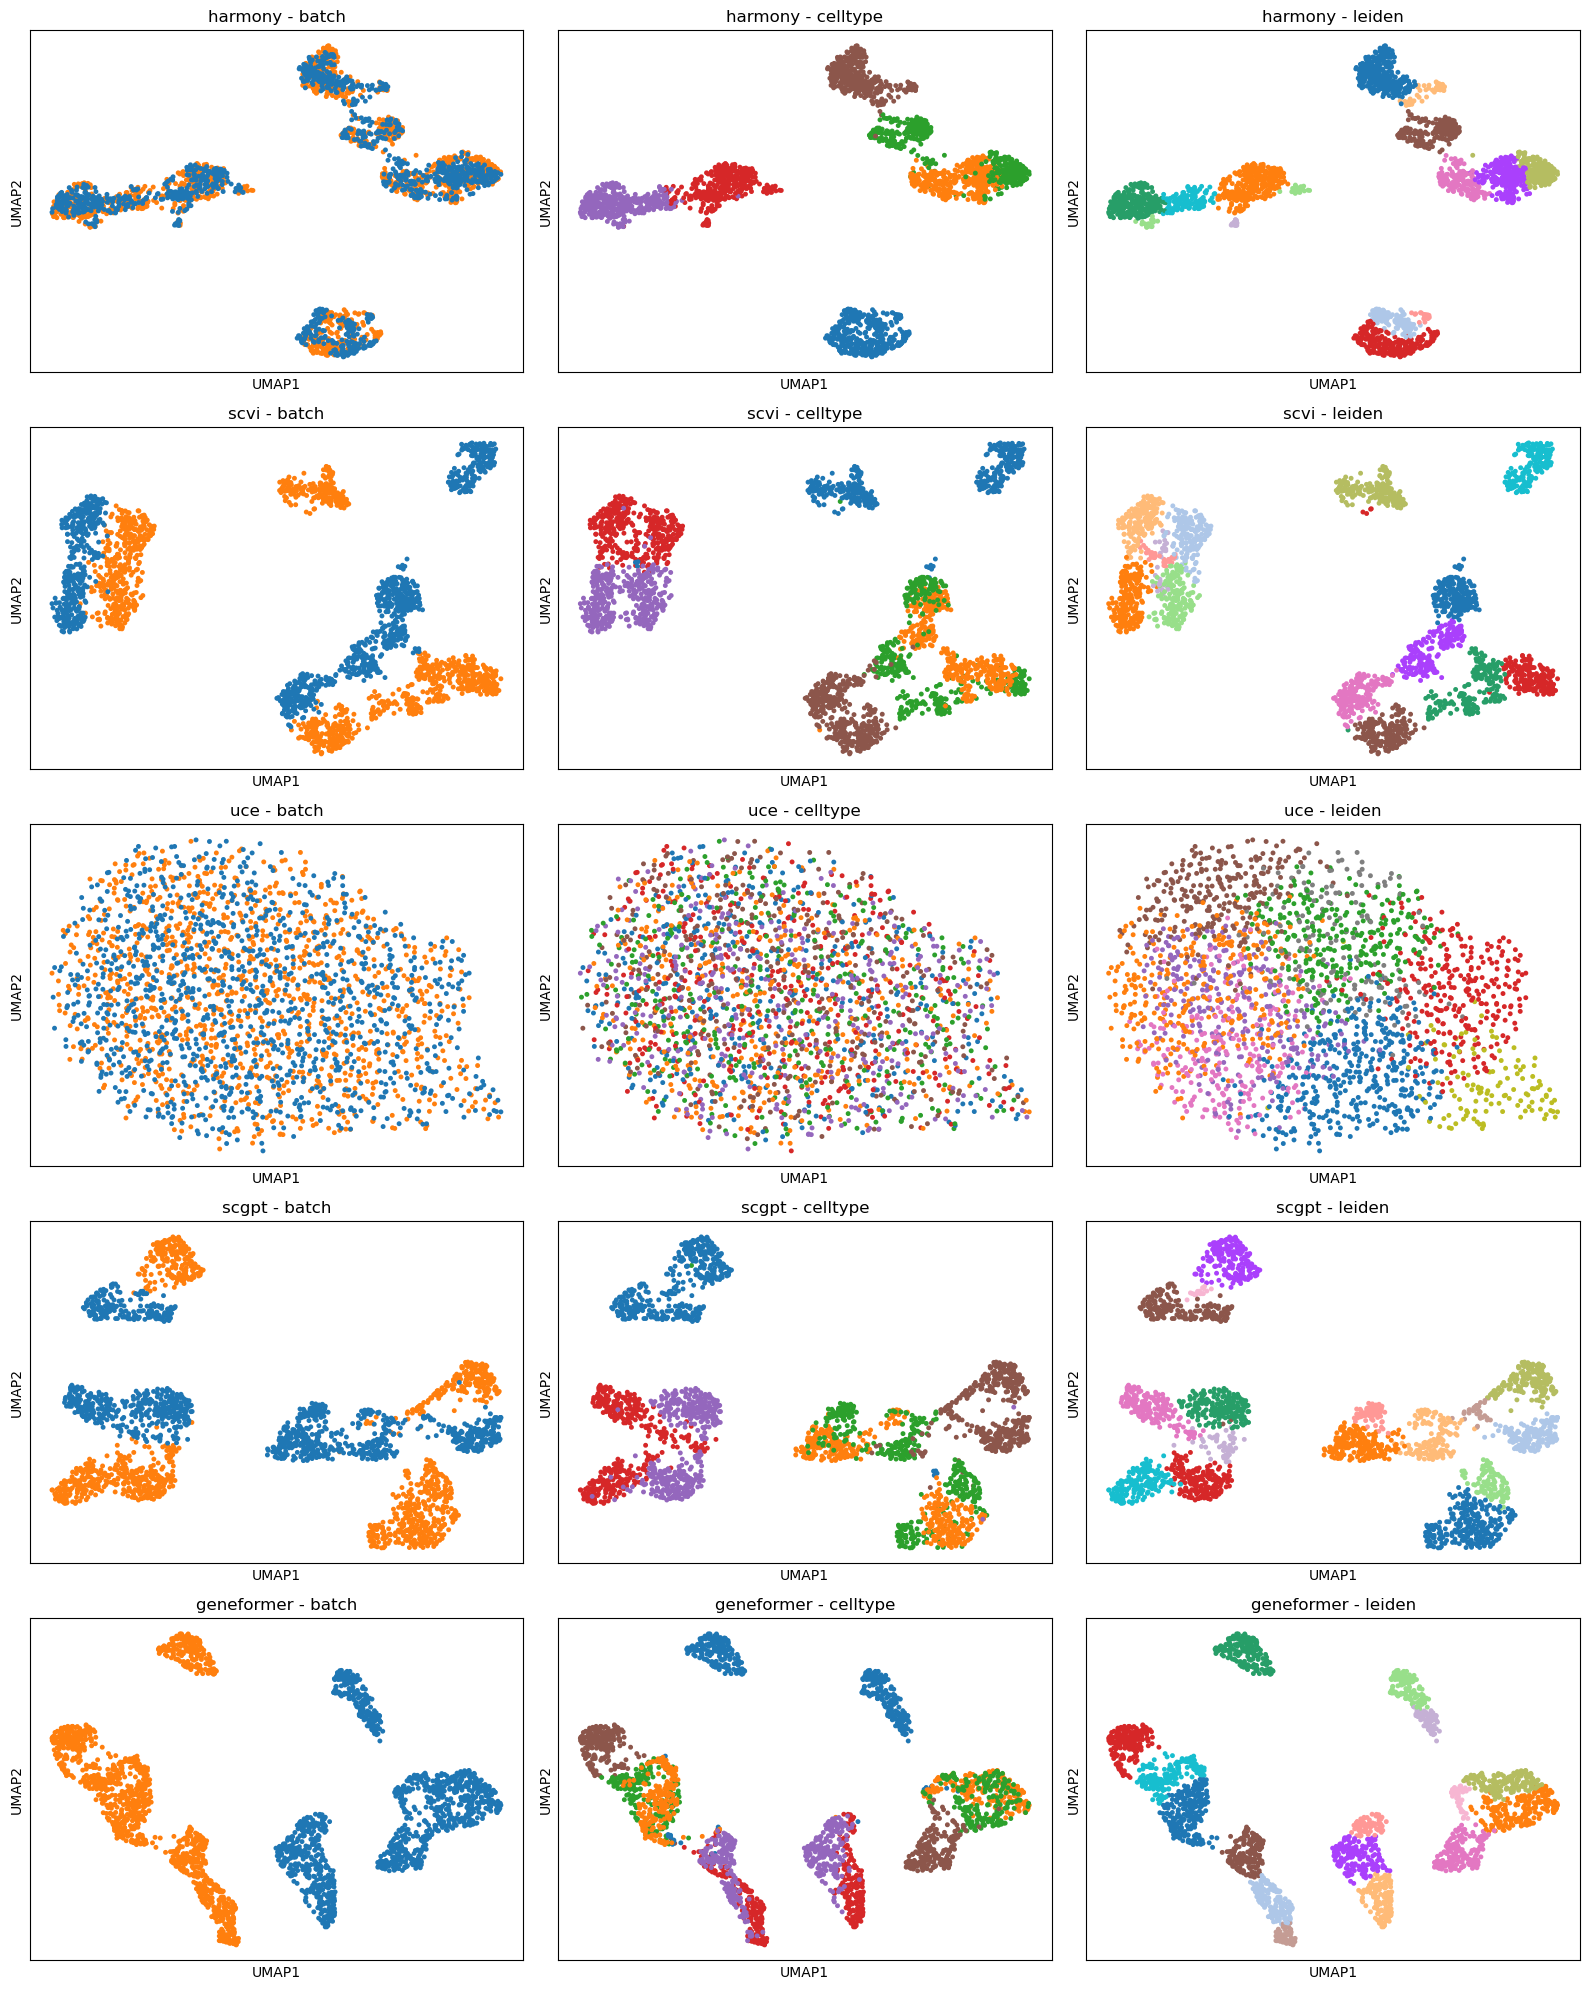

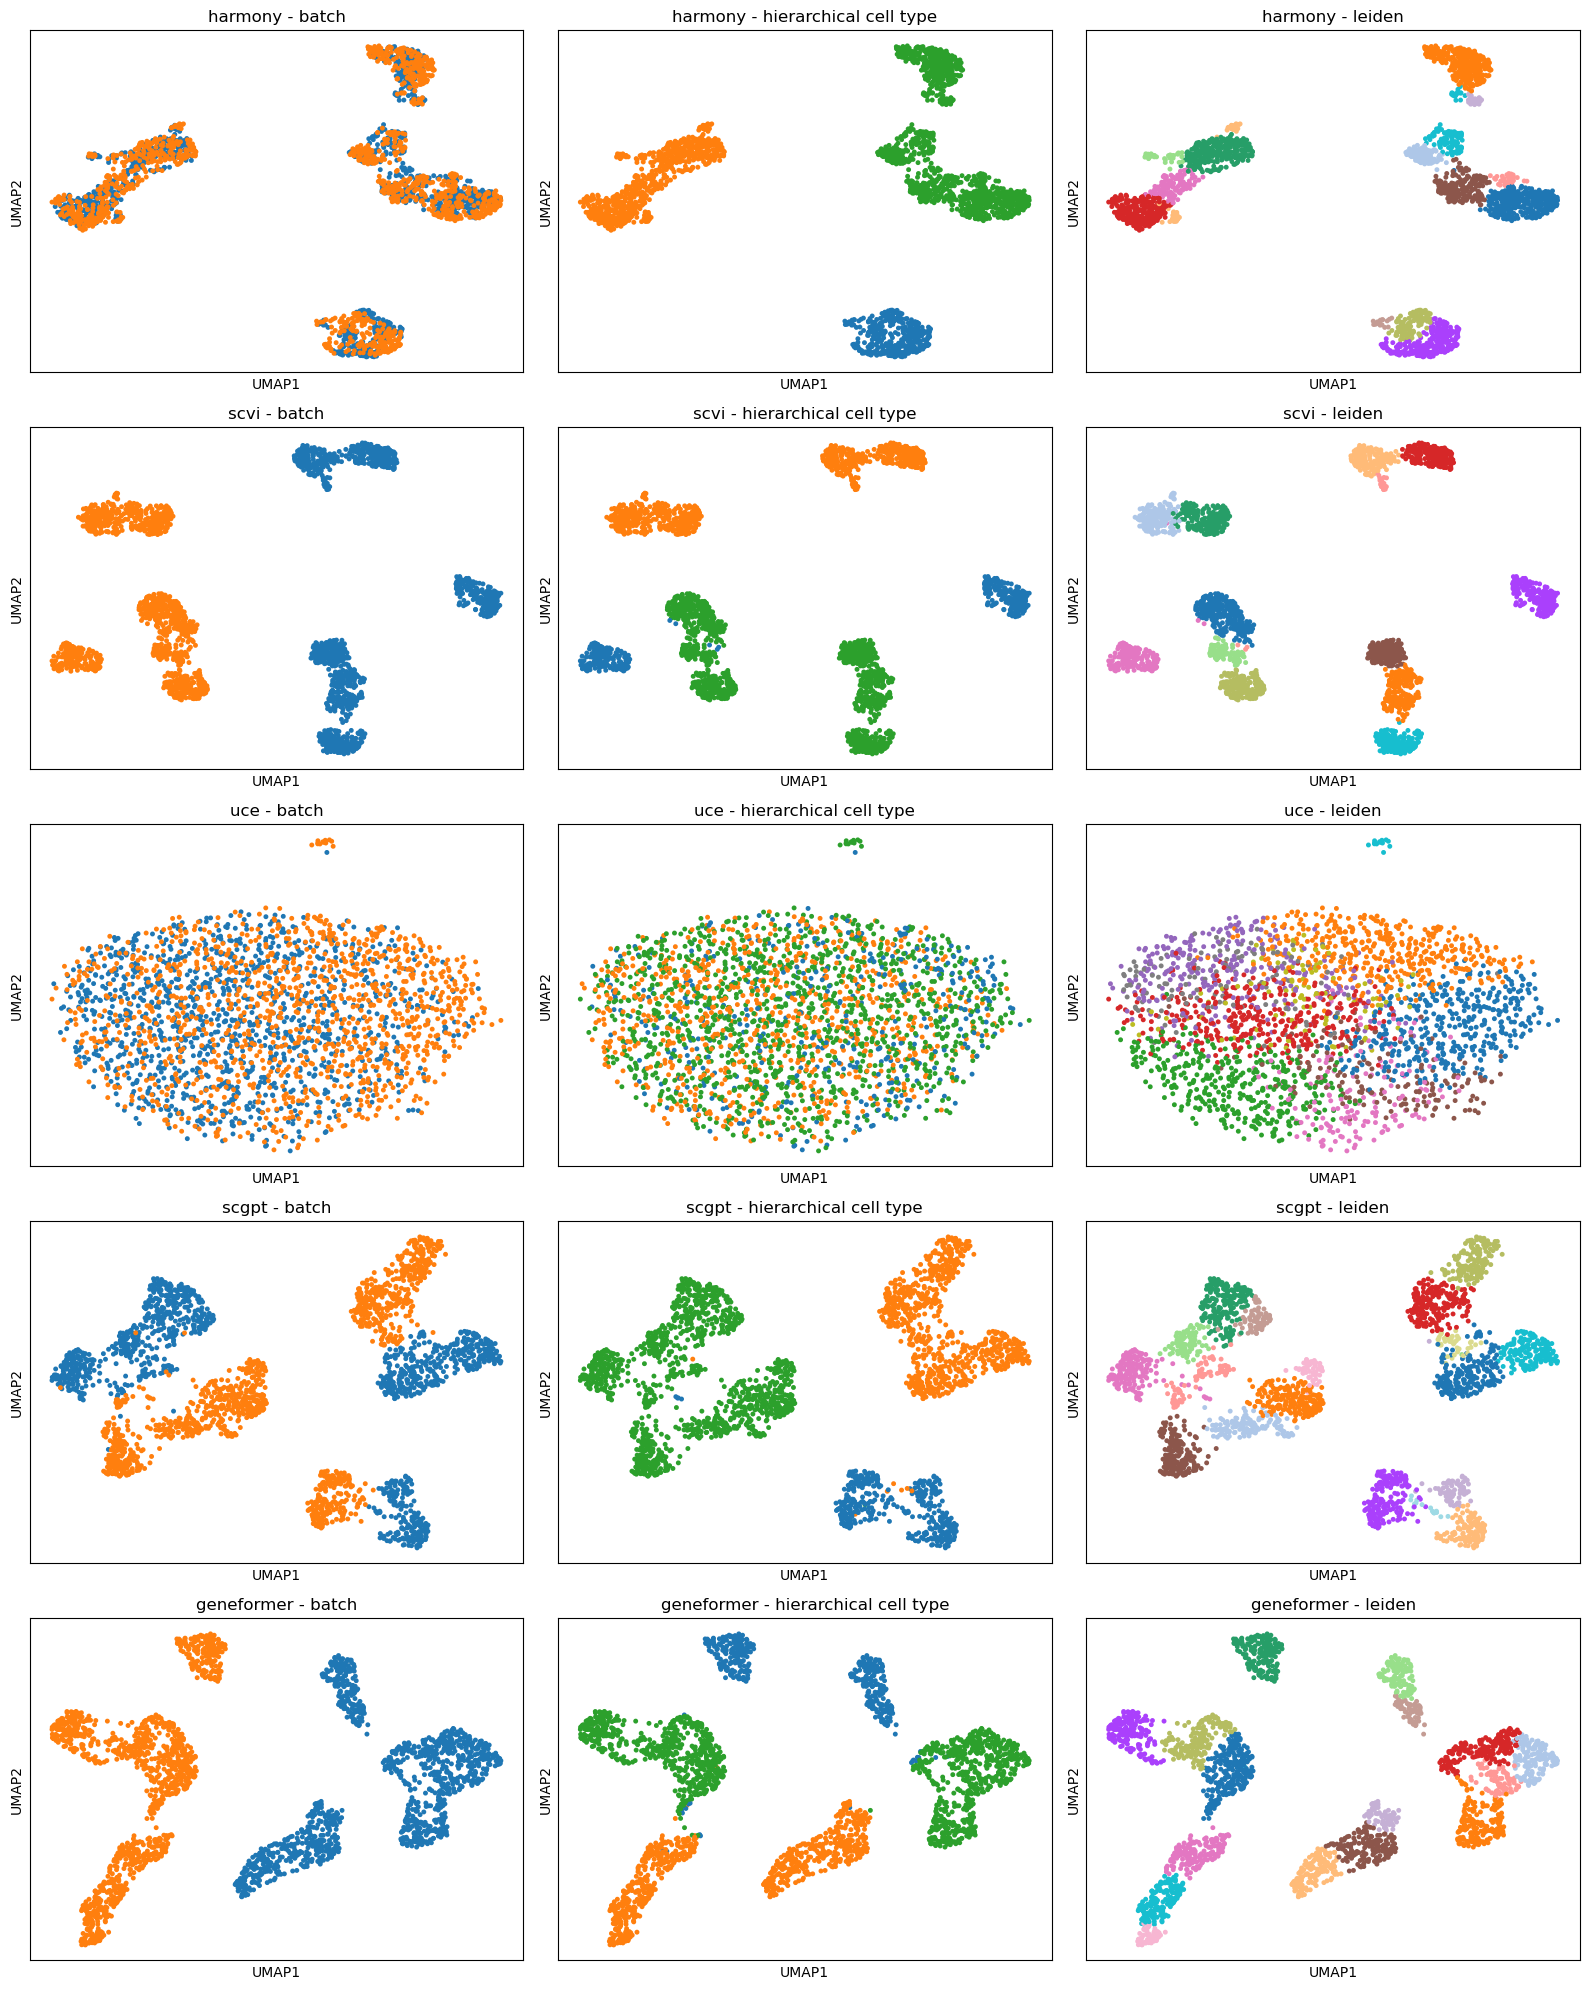

In [33]:
# plotting UMAPs with specific cell types (use the same code block as the ones I used for the final paper)
methods = integration_method.unique()
attributes = ['batch', 'celltype', 'leiden']

# Create 5x3 plot
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

# Plot each UMAP
for i, method in enumerate(methods):
    if method == "uce":
        adata = adata_c_uce
    elif method == "scgpt":
        adata = adata_c_scgpt
    elif method == "geneformer":
        adata = adata_c_geneformer
    elif method == "harmony":
        adata = adata_c_harmony
    elif method == "scvi":
        adata = adata_c_scvi

    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_kmeans')
        sc.tl.leiden(adata, resolution=1.0)
        sc.tl.umap(adata)
        sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - {attr}', legend_loc='none')

plt.tight_layout()
plt.savefig("control_umap_celltype.png", dpi=300, bbox_inches='tight')
plt.show()

########################################################
# Create 5x3 plot
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

# Plot each UMAP
for i, method in enumerate(methods):
    if method == "uce":
        adata = adata_h_uce
    elif method == "scgpt":
        adata = adata_h_scgpt
    elif method == "geneformer":
        adata = adata_h_geneformer
    elif method == "harmony":
        adata = adata_h_harmony
    elif method == "scvi":
        adata = adata_h_scvi

    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_kmeans')
        sc.tl.leiden(adata, resolution=1.0)
        sc.tl.umap(adata)
        if j == 1:
            sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - hierarchical cell type', legend_loc='none')
        else:
            sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - {attr}', legend_loc='none')
            
plt.tight_layout()
plt.savefig("control_umap_hier.png", dpi=300, bbox_inches='tight')
plt.show()

